# Aprendizaje de Variedades y Reducción de Dimensión Mediante Autoencoders

**Diego Moñino — Trabajo de Fin de Grado (Matemáticas)**

Este *notebook* implementa el experimento completo que acompaña al capítulo
de metodología. La tesis defiende que los autoencoders —en particular las
variantes **variacional (VAE)** y **de *denoising* (DAE)**— son herramientas
efectivas para el aprendizaje de variedades y la reducción de dimensión.

El notebook **orquesta** funciones reutilizables definidas en los módulos del
repositorio (`data/`, `models/`, `dimension_estimation/`, `evaluation/`,
`experiments/`); no contiene lógica suelta. Se organiza en 11 pasos:

1. **Preparación** — interfaz común de datos y de métricas (incl. dimensión
   efectiva vía jacobiano del decoder).
2. **Datasets sintéticos** — Swiss Roll y variedad lineal $H_{3,30}$: cada
   uno es una única variedad conexa, con dimensión intrínseca bien definida.
3. **Estimación de dimensión intrínseca** — los tres estimadores, uno por
   celda con su diagnóstico gráfico; fija la dimensión latente $d$ de todos
   los modelos por dataset.
4. **AE lineal vs PCA** — ángulos principales entre subespacios.
5. **AE no lineal y sus límites** — diagnósticos de huecos y sensibilidad.
6. **VAE y DAE** — mismos diagnósticos.
7. **Segunda estimación de dimensión** desde el decoder entrenado.
8. **Comparación final** (Swiss Roll + lineal) — tabla única de métricas +
   discusión.
9. **Datasets múltiples** — por qué MNIST y COIL-20 completos (uniones de
   varias variedades: 10 clases de dígito / 20 objetos) se tratan aparte.
10. **MNIST completo** — se usa la mezcla de las 10 clases *a propósito*:
    ¿separa el autoencoder los dígitos en el latente pese a entrenarse con
    una dimensión inflada por esa misma mezcla?
11. **COIL-20: un solo objeto** — se aísla un objeto (variedad de rotación
    pura) y se estima/entrena con su propia dimensión intrínseca.

> **Nota de reproducibilidad.** Todas las funciones aceptan un parámetro
> `seed`; el experimento se puede relanzar con varias semillas cambiando una
> única constante. En esta primera pasada se usa una sola semilla.

---
## Configuración e importaciones

Situamos el directorio de trabajo en la raíz del repositorio para que las
rutas relativas (`data/raw/`, `results/`) coincidan con las que asumen los
módulos, e importamos las funciones reutilizables.

In [68]:
%matplotlib inline
import os, sys, json
import numpy as np
import torch
import matplotlib.pyplot as plt

# Ejecutar desde la raíz del repositorio (el notebook vive en notebooks/).
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
REPO_ROOT = os.getcwd()
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Datos y ruido
from data.datasets import get_dataset_with_meta
from data.noise import get_noise_fn, suggest_dae_sigma
# Modelos y pérdidas
from models.autoencoder import build_linear_ae, build_dae
from models.vae import build_vae
from models.losses import dae_loss, vae_loss_gamma
# Entrenamiento y configuración
from experiments.training import set_seed, train_model, get_latent, reconstruct
from experiments.config import save_experiment_config, load_experiment_config, get_latent_dim
# Estimación de dimensión
from dimension_estimation.aggregate import estimate_all_dimensions, choose_latent_dim
# Evaluación
from evaluation.metrics import evaluate_common_metrics, effective_dimension_jacobian
from evaluation.linear_pca import compare_ae_pca
from evaluation.diagnostics import latent_hole_probe, noise_sensitivity

FIG_DIR = os.path.join("results", "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print("Repositorio:", REPO_ROOT)

Repositorio: c:\Users\monin\Documents\Aprendizaje-de-Variedades-y-Reduccion-de-Dimension-mediante-Autoencoders


### Constantes globales

> **Coste computacional.** Esta primera pasada prioriza *rapidez y
> funcionalidad*: se **submuestrean** los datasets (3000–5000 puntos) y se
> usan 150 épocas. Los valores están centralizados aquí para escalarlos de una
> sola vez cuando se busque mayor fidelidad.

In [ ]:
SEED   = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Hiperparámetros de los modelos (fijos, no aprendidos)
GAMMA  = 0.05   # VAE: alpha = 1/(2*gamma) pondera la reconstrucción
BETA   = 1.0    # VAE: peso del término KL (beta-VAE)
EPOCHS = 150
LR     = 1e-3
DAE_SIGMA_K        = 10     # k-ésimo vecino para la heurística de sigma
DAE_SIGMA_FRACTION = 0.10   # fracción de la mediana de distancia al k-NN

# Datasets sintéticos: cada uno es UNA variedad única y conexa, así que su
# dimensión intrínseca está bien definida (Pasos 2-8). MNIST y COIL-20
# completos son uniones de varias variedades (10 clases / 20 objetos) y se
# tratan aparte en los Pasos 9-11. n_max = tope para geom-prob.
SPECS = {
    "swiss_roll": dict(kwargs=dict(n_samples=3000, noise=0.0),                         n_max=7),
    "linear":     dict(kwargs=dict(n_samples=5000, intrinsic_dim=3, ambient_dim=30),   n_max=7),
}

# Contenedores compartidos entre pasos (se rellenan progresivamente).
DATA    = {}   # name -> (dataset, meta, X)
TRAINED = {}   # name -> {model_name: model}
LATENT  = {}   # name -> {model_name: z}
LOSSES  = {}   # name -> {model_name: [loss por época]} -- para las curvas de convergencia

set_seed(SEED)
print("Device:", DEVICE)

---
## Paso 1 — Preparación: interfaz común de datos y métricas

Toda la infraestructura reutilizable ya vive en los módulos del repositorio:

- **Carga unificada de datos** con metadatos: `get_dataset_with_meta(name, ...)`
  devuelve el dataset y un diccionario con la dimensión ambiente y la
  dimensión intrínseca *esperada*.
- **Métricas comunes** (`evaluation/metrics.py`, `evaluation/topology.py`):
  error de reconstrucción (MSE), *trustworthiness* (vía `sklearn`) y
  *continuity* (su contraparte simétrica basada en rangos, ya implementada en
  el repo), y la **dimensión efectiva vía jacobiano del decoder**.

Sobre esta última: el decoder $g:\mathbb{R}^d\to\mathbb{R}^D$ parametriza la
variedad aprendida; su jacobiano $J=\partial g/\partial z$ genera el espacio
tangente. El número de valores singulares de $J$ por encima de un umbral
relativo (1 % del mayor) es la **dimensión local** de la variedad imagen.
Se calcula con `torch.func.jacfwd` + `vmap` (jacobiano exacto y *batcheado*; modo *forward* deliberadamente, porque el decoder va de una dimensión latente baja $d$ a una dimensión ambiente alta $D$ -- su coste escala con $d$, no con $D$, evitando un desbordamiento de memoria en datasets de imagen como COIL-20, $D=16384$).

Verificamos la herramienta sobre un decoder de juguete $\mathbb{R}^2\to\mathbb{R}^3$
(dimensión local esperada $\approx 2$):

In [70]:
_toy = build_dae(input_dim=3, latent_dim=2)
_toy_jac = effective_dimension_jacobian(_toy.decode, torch.randn(64, 2), rel_threshold=0.01)
print(f"Decoder R^2 -> R^3  ->  dimensión efectiva estimada: {_toy_jac['effective_dim']:.2f}  (esperado ~2)")

Decoder R^2 -> R^3  ->  dimensión efectiva estimada: 2.00  (esperado ~2)


---
## Paso 2 — Datasets sintéticos

Cargamos los dos datasets sintéticos, cada uno una **única variedad conexa**
con dimensión intrínseca conocida por construcción:

- **Swiss Roll**: lámina 2D curvada en $\mathbb{R}^3$; dimensión intrínseca
  conocida $= 2$.
- **Variedad lineal $H_{3,30}$**: muestra en un subespacio de dimensión 3
  embebido en $\mathbb{R}^{30}$ (Ivanov et al., 2021); dimensión intrínseca
  conocida $= 3$.

MNIST y COIL-20 **no** entran aquí: cada uno es la unión de varias variedades
(10 clases de dígito / 20 objetos), no una única variedad, así que "su"
dimensión intrínseca no está bien definida de la misma forma. Se tratan
aparte en los Pasos 9-11: MNIST se estudia **completo** y a propósito (Paso
10), y de COIL-20 se **aísla un solo objeto** (Paso 11).

In [ ]:
for name, spec in SPECS.items():
    ds, meta = get_dataset_with_meta(name, **spec["kwargs"])
    DATA[name] = (ds, meta, ds.data.numpy())
    TRAINED[name] = {}
    LATENT[name]  = {}
    LOSSES[name]  = {}
    print(f"{name:11s}  data={tuple(ds.data.shape)}  "
          f"ambient_dim={meta['ambient_dim']:4d}  "
          f"dim_esperada={meta['expected_intrinsic_dim']}")

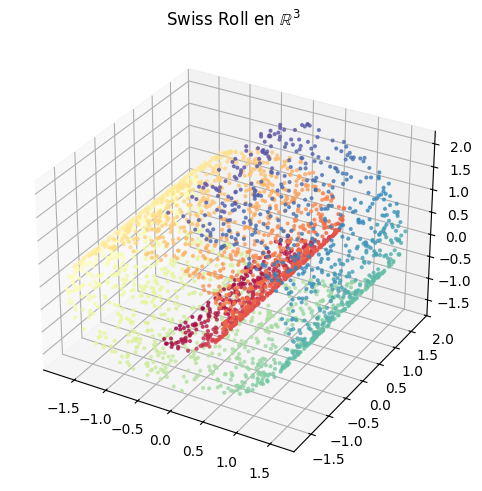

In [72]:
# Visualización: Swiss Roll en 3D (la variedad lineal, en R^30, no se
# presta a una visualización directa).
ds_sr, meta_sr, X_sr = DATA["swiss_roll"]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection="3d")
ax.scatter(X_sr[:, 0], X_sr[:, 1], X_sr[:, 2], c=ds_sr.labels, cmap="Spectral", s=4, alpha=0.7)
ax.set_title("Swiss Roll en $\\mathbb{R}^3$")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step2_datasets.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Paso 3 — Estimación de la dimensión intrínseca

Aplicamos los **tres estimadores ya implementados** en el repositorio sobre
los dos datasets, uno por celda y cada uno con su diagnóstico gráfico:

1. **Geométrico-probabilístico** (Ivanov et al.) — `estimate_dimension`:
   para cada dimensión candidata $n$ compara $A_1^2(n)$ con $A_2(n)$ (media
   al cuadrado frente a varianza de $V^n(d_{\min})$, que coinciden si la
   distribución es exponencial) y mide la calidad del ajuste con el
   estadístico de Kolmogorov–Smirnov; el $n$ elegido es el que **minimiza
   KS**.
2. **Minkowski** (conteo de cajas) — `minkowski_dimension`: la dimensión es
   la **pendiente** de $\log N(r)$ frente a $-\log r$ en el régimen lineal.
3. **PCA** — `estimate_dimension_pca`: número de componentes **lineales**
   necesarias para explicar el 95 % de la varianza (más el *participation
   ratio*, su versión continua).
4. **Tabla resumen**, que reúne los tres estimadores y **fija la dimensión
   latente $d$** que usarán todos los modelos de los pasos siguientes.

Regla de elección: se confía en el estimador geométrico-probabilístico
(entero y diseñado para dimensión intrínseca). El valor se guarda en
`results/experiment_config.json` y se lee en los pasos posteriores con
`get_latent_dim(name)`.

swiss_roll  geométrico-probabilístico -> d = 2  (esperada: 2)
linear      geométrico-probabilístico -> d = 3  (esperada: 3)


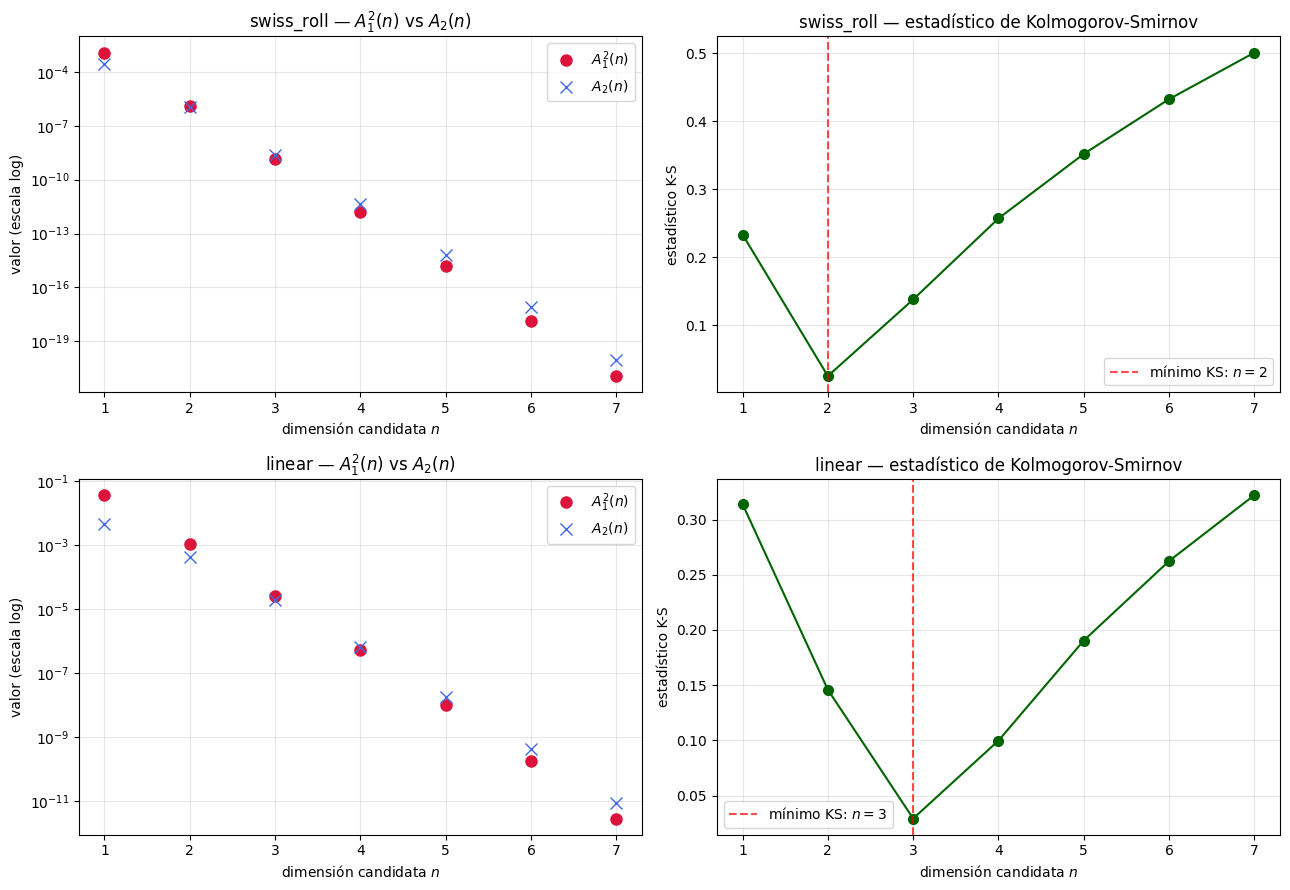

In [73]:
# Paso 3.1 — estimador geométrico-probabilístico (Ivanov et al.).
# Panel izquierdo: A1^2(n) frente a A2(n) en escala log (deben cruzarse en
# la dimensión correcta). Panel derecho: estadístico KS, cuyo mínimo fija
# el n elegido. Una fila por dataset, sin solapamiento entre paneles.
from dimension_estimation.geometric_prob import estimate_dimension

GEO = {}   # name -> (dimensión estimada, dict `results` completo)

fig, axes = plt.subplots(len(SPECS), 2, figsize=(13, 4.5 * len(SPECS)))
axes = np.atleast_2d(axes)
for row, (name, spec) in enumerate(SPECS.items()):
    ds, meta, X = DATA[name]
    geo, geo_res = estimate_dimension(X, n_min=1, n_max=spec["n_max"])
    GEO[name] = (geo, geo_res)

    cand = geo_res["candidates"]
    ax1, ax2 = axes[row, 0], axes[row, 1]

    ax1.plot(cand, geo_res["A1_sq_vals"], "o", color="crimson", markersize=8, label="$A_1^2(n)$")
    ax1.plot(cand, geo_res["A2_vals"], "x", color="royalblue", markersize=9, label="$A_2(n)$")
    ax1.set_yscale("log")
    ax1.set_xlabel("dimensión candidata $n$"); ax1.set_ylabel("valor (escala log)")
    ax1.set_title(f"{name} — $A_1^2(n)$ vs $A_2(n)$")
    ax1.set_xticks(cand); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(cand, geo_res["ks_vals"], "o-", color="darkgreen", markersize=7)
    ax2.axvline(geo, color="red", linestyle="--", alpha=0.7, label=f"mínimo KS: $n = {geo}$")
    ax2.set_xlabel("dimensión candidata $n$"); ax2.set_ylabel("estadístico K-S")
    ax2.set_title(f"{name} — estadístico de Kolmogorov-Smirnov")
    ax2.set_xticks(cand); ax2.legend(); ax2.grid(True, alpha=0.3)

    print(f"{name:11s} geométrico-probabilístico -> d = {geo}  "
          f"(esperada: {meta['expected_intrinsic_dim']})")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step3_geometric_prob.png"), dpi=150, bbox_inches="tight")
plt.show()

swiss_roll  Minkowski -> 1.82  (pendiente del ajuste sobre la curva completa: 1.24)
linear      Minkowski -> 2.30  (pendiente del ajuste sobre la curva completa: 0.77)


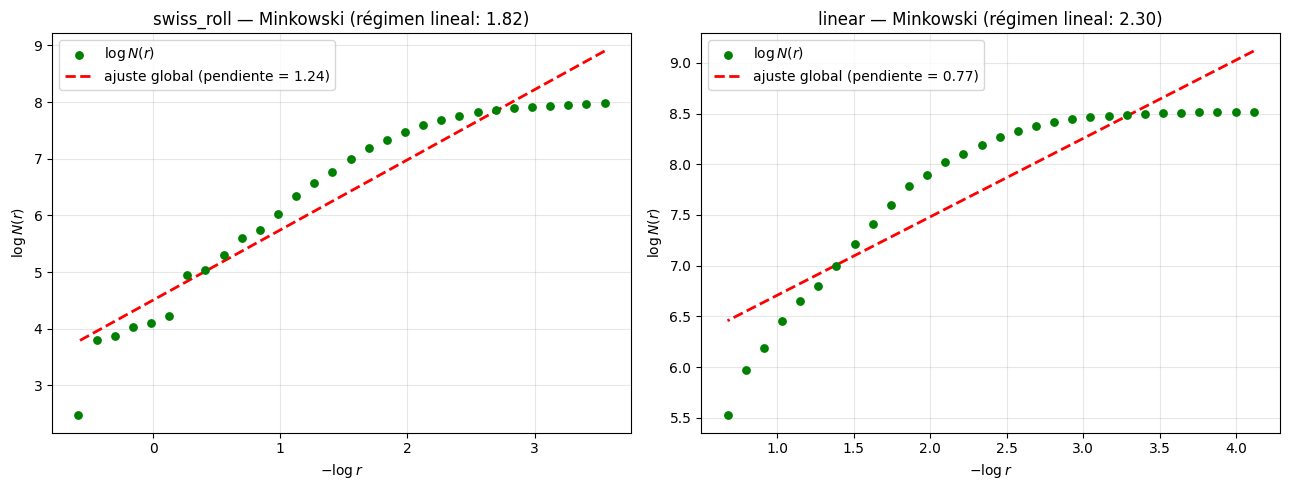

In [74]:
# Paso 3.2 — dimensión de Minkowski (conteo de cajas): la pendiente de
# log N(r) frente a -log r. En dimensión ambiente alta el estimador puede
# no encontrar ningún régimen de escala lineal y lanzar ValueError (ver
# Pasos 10 y 11); aquí D es baja en ambos datasets, pero se captura igual
# por consistencia con el resto del notebook.
from dimension_estimation.minkowski import minkowski_dimension

MINK = {}   # name -> dimensión estimada (NaN si degenera)

fig, axes = plt.subplots(1, len(SPECS), figsize=(6.5 * len(SPECS), 5))
axes = np.atleast_1d(axes)
for ax, (name, spec) in zip(axes, SPECS.items()):
    ds, meta, X = DATA[name]
    try:
        mink, neg_log_r, log_N = minkowski_dimension(X)
    except ValueError:
        MINK[name] = float("nan")
        ax.text(0.5, 0.5, "régimen lineal\nno encontrado", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(f"{name} — Minkowski (degenerado)")
        print(f"{name:11s} Minkowski: régimen lineal no encontrado "
              f"(D={meta['ambient_dim']}) -> NaN")
        continue

    MINK[name] = float(mink)
    coeffs = np.polyfit(neg_log_r, log_N, deg=1)
    ax.scatter(neg_log_r, log_N, color="green", s=28, zorder=3, label="$\\log N(r)$")
    ax.plot(neg_log_r, np.polyval(coeffs, neg_log_r), "r--", linewidth=2,
            label=f"ajuste global (pendiente = {coeffs[0]:.2f})")
    ax.set_xlabel("$-\\log r$"); ax.set_ylabel("$\\log N(r)$")
    ax.set_title(f"{name} — Minkowski (régimen lineal: {mink:.2f})")
    ax.legend(); ax.grid(True, alpha=0.3)

    print(f"{name:11s} Minkowski -> {mink:.2f}  "
          f"(pendiente del ajuste sobre la curva completa: {coeffs[0]:.2f})")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step3_minkowski.png"), dpi=150, bbox_inches="tight")
plt.show()

swiss_roll  PCA95 -> 3 componentes  (participation ratio: 2.98)
linear      PCA95 -> 3 componentes  (participation ratio: 3.00)


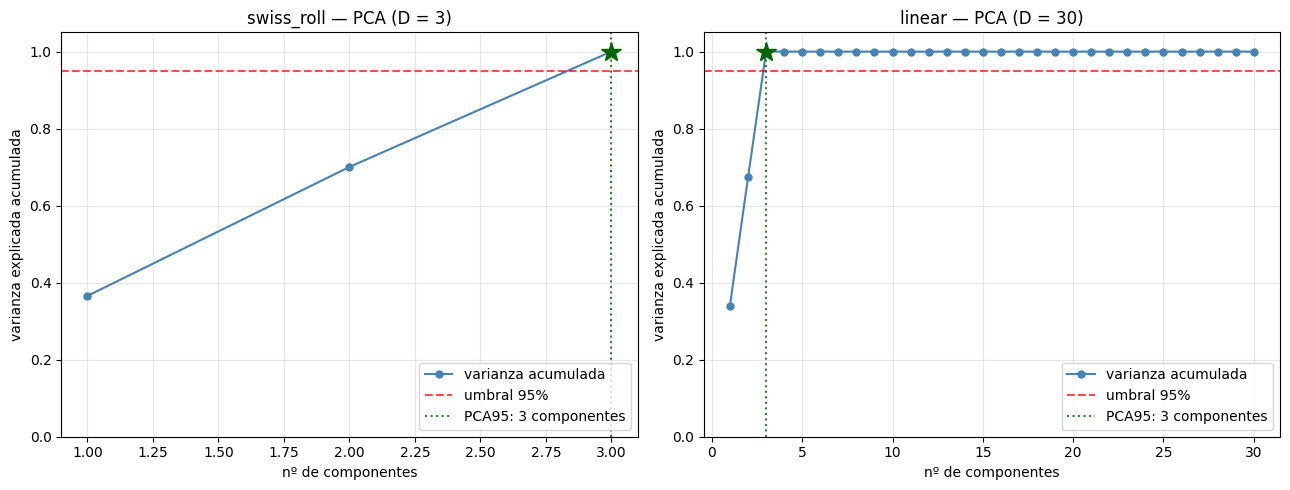

In [75]:
# Paso 3.3 — PCA: varianza explicada acumulada frente al número de
# componentes, con el umbral del 95 % (línea horizontal) y el número de
# componentes elegido (línea vertical + marca).
from dimension_estimation.pca import estimate_dimension_pca

PCA_RES = {}   # name -> dict devuelto por estimate_dimension_pca

fig, axes = plt.subplots(1, len(SPECS), figsize=(6.5 * len(SPECS), 5))
axes = np.atleast_1d(axes)
for ax, (name, spec) in zip(axes, SPECS.items()):
    ds, meta, X = DATA[name]
    pca_res = estimate_dimension_pca(X, threshold=0.95)
    PCA_RES[name] = pca_res

    cum = pca_res["cumulative_variance"]
    k = np.arange(1, len(cum) + 1)
    k95 = pca_res["variance_threshold_dim"]

    ax.plot(k, cum, "o-", color="steelblue", markersize=5, label="varianza acumulada")
    ax.axhline(pca_res["threshold"], color="red", linestyle="--", alpha=0.7,
               label=f"umbral {pca_res['threshold']:.0%}")
    ax.axvline(k95, color="darkgreen", linestyle=":", alpha=0.8,
               label=f"PCA95: {k95} componentes")
    ax.plot([k95], [cum[k95 - 1]], marker="*", markersize=15, color="darkgreen", zorder=4)
    ax.set_xlabel("nº de componentes"); ax.set_ylabel("varianza explicada acumulada")
    ax.set_title(f"{name} — PCA (D = {meta['ambient_dim']})")
    ax.set_ylim(0, 1.05); ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)

    print(f"{name:11s} PCA95 -> {k95} componentes  "
          f"(participation ratio: {pca_res['participation_ratio_dim']:.2f})")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step3_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

In [76]:
# Paso 3.4 — tabla resumen: reúne los tres estimadores por dataset, fija d
# con `choose_latent_dim` (regla: geométrico-probabilístico) y guarda la
# configuración que leerán los Pasos 4-8 vía `get_latent_dim(name)`.
config = {}
print(f"{'dataset':11s} {'esperada':>8s} {'Minkowski':>10s} {'GeomProb':>9s} "
      f"{'PCA95':>6s} {'PCA-PR':>7s} {'-> d':>5s}")
for name, spec in SPECS.items():
    ds, meta, X = DATA[name]
    geo, geo_res = GEO[name]
    pca_res = PCA_RES[name]
    est = {
        "minkowski": float(MINK[name]),
        "geometric_prob": int(geo),
        "pca_threshold": int(pca_res["variance_threshold_dim"]),
        "pca_participation": float(pca_res["participation_ratio_dim"]),
        "geometric_prob_ks": [float(v) for v in geo_res["ks_vals"]],
    }
    d = choose_latent_dim(est, expected=meta["expected_intrinsic_dim"])
    config[name] = {"ambient_dim": meta["ambient_dim"],
                    "expected_intrinsic_dim": meta["expected_intrinsic_dim"],
                    "estimates": est, "latent_dim": d}
    print(f"{name:11s} {str(meta['expected_intrinsic_dim']):>8s} "
          f"{est['minkowski']:>10.2f} {est['geometric_prob']:>9d} "
          f"{est['pca_threshold']:>6d} {est['pca_participation']:>7.2f} {d:>5d}")

save_experiment_config(config)
print("\nConfiguración guardada en results/experiment_config.json")

dataset     esperada  Minkowski  GeomProb  PCA95  PCA-PR  -> d
swiss_roll         2       1.82         2      3    2.98     2
linear             3       2.30         3      3    3.00     3

Configuración guardada en results/experiment_config.json


**Lectura de los resultados.**

- *Swiss Roll*: el método geométrico-probabilístico acierta ($d=2$) — el
  mínimo del estadístico KS cae limpiamente en $n=2$; PCA sobreestima
  (necesita 3 direcciones lineales para una variedad **curva**), ilustrando
  la limitación que motiva los métodos no lineales.
- *$H_{3,30}$*: geométrico-probabilístico y PCA coinciden en 3 (variedad
  **lineal** → PCA la recupera exacta, y la curva de varianza acumulada
  satura de golpe en la tercera componente); Minkowski infraestima por
  tamaño de muestra (limitación documentada en `minkowski.py`, no un error).

La celda 3.4 es la única que **fija** algo: el resto son diagnósticos. La $d$
elegida ahí es la que leen los Pasos 4-8 con `get_latent_dim(name)`.

(MNIST y COIL-20 no se estiman aquí: al ser uniones de varias variedades, ver
Paso 9. La estimación de dimensión se retoma en el Paso 10 — sobre MNIST
**completo**, a propósito — y en el Paso 11 — sobre un **único objeto** de
COIL-20.)

---
## Paso 4 — Autoencoder lineal frente a PCA

Entrenamos un autoencoder **sin no linealidades** con la $d$ fijada en el
Paso 3 y comparamos el subespacio recuperado con el de PCA mediante **ángulos
principales** (`scipy.linalg.subspace_angles`). Por el teorema de Baldi &
Hornik (1989), un AE lineal con pérdida MSE converge al subespacio principal:
esperamos ángulos $\approx 0°$ y MSE de reconstrucción idéntico al de PCA.

In [ ]:
print(f"{'dataset':11s} {'d':>2s} {'AE MSE':>9s} {'PCA MSE':>9s} {'áng. máx (°)':>13s}")
for name, spec in SPECS.items():
    ds, meta, X = DATA[name]
    d = get_latent_dim(name)
    set_seed(SEED)
    model = build_linear_ae(meta["ambient_dim"], latent_dim=d)
    losses = train_model(model, ds, dae_loss, epochs=EPOCHS, lr=5e-3, device=DEVICE, seed=SEED,
                         desc=f"{name} · linear_AE")
    LOSSES[name]["linear_AE"] = losses
    cmp = compare_ae_pca(model, X, d)
    TRAINED[name]["linear_AE"] = model
    LATENT[name]["linear_AE"]  = get_latent(model, ds, device=DEVICE)
    print(f"{name:11s} {d:>2d} {cmp['ae_mse']:>9.4f} {cmp['pca_mse']:>9.4f} "
          f"{cmp['max_angle_deg']:>13.2f}")

In [ ]:
# Curvas de pérdida del AE lineal (una por dataset): comprueban que EPOCHS
# épocas basta para converger antes de comparar con PCA.
fig, axes = plt.subplots(1, len(SPECS), figsize=(6 * len(SPECS), 4))
for ax, name in zip(np.atleast_1d(axes), SPECS):
    ax.plot(LOSSES[name]["linear_AE"])
    ax.set_title(f"{name} — AE lineal"); ax.set_xlabel("época"); ax.set_ylabel("loss (MSE)")
    ax.set_yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step4_loss_curves_linear_AE.png"), dpi=150, bbox_inches="tight")
plt.show()

Los ángulos principales cercanos a $0°$ y la coincidencia de MSE confirman que
el AE lineal recupera el **mismo subespacio** que PCA. En el Swiss Roll ambos
dan un MSE alto: un subespacio **lineal** 2D no puede desenrollar la variedad
curva — justo la limitación que aborda el AE no lineal en el Paso 5.

Comprobamos la afirmación anterior **visualmente**. Conviene ser precisos con
lo que predice Baldi & Hornik: el AE lineal y PCA recuperan el mismo
**subespacio**, no la misma **base**. El código del AE es, por tanto, una
transformación **afín invertible** del de PCA — el AE tiene sesgos, así que
su código ni siquiera está centrado, y el cambio de base no tiene por qué ser
una isometría.

Sobre el Swiss Roll ($d=2$, fácil de visualizar) calculamos PCA directamente,
**centramos** ambos códigos y alineamos el de PCA con el del AE usando la
**parte rígida** de esa transformación: la rotación ortogonal óptima
(Procrustes, `scipy.linalg.orthogonal_procrustes`) seguida del factor de
escala uniforme óptimo. Si tras alinear ambos códigos son prácticamente
idénticos, queda confirmado que solo difieren en un cambio de base dentro del
mismo subespacio; el residuo que quede mide la parte **no ortogonal**
(cizalla) que el teorema permite.

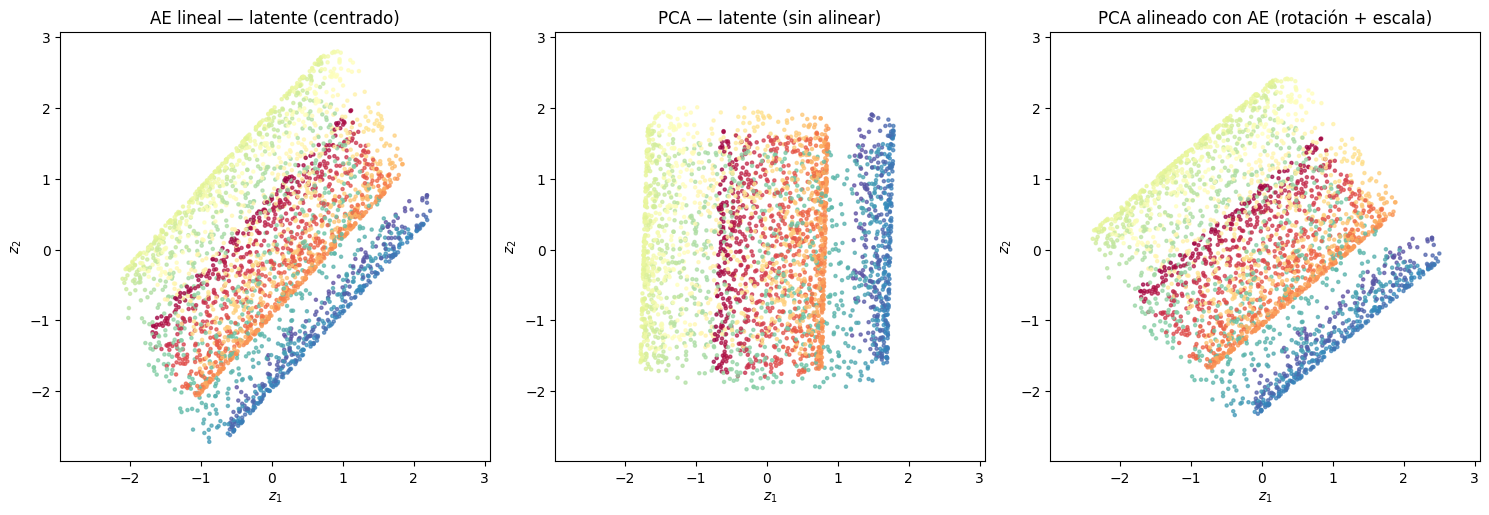

Swiss Roll — escala uniforme óptima: 0.998
MSE residual tras alinear (centrado + rotación + escala): 0.072224  (6.5 % de la varianza del código del AE)
Lo que queda es la parte NO ortogonal del cambio de base (cizalla): Baldi &
Hornik garantizan el mismo subespacio -- confirmado arriba por los ángulos
principales ~ 0° -- pero no la misma base ortonormal.


In [78]:
# Swiss Roll: espacio latente del AE lineal vs PCA (deben coincidir salvo un
# cambio de base dentro del mismo subespacio).
from sklearn.decomposition import PCA
from scipy.linalg import orthogonal_procrustes

ds, meta, X = DATA["swiss_roll"]
d = get_latent_dim("swiss_roll")
z_ae = LATENT["swiss_roll"]["linear_AE"]

pca = PCA(n_components=d)
z_pca = pca.fit_transform(X)

# PCA centra sus códigos por construcción; el AE lineal, que tiene sesgos, no.
# Centramos ambos y alineamos con la parte RÍGIDA del cambio de base: rotación
# ortogonal óptima (Procrustes) + factor de escala uniforme óptimo.
z_ae_c  = z_ae - z_ae.mean(axis=0)
z_pca_c = z_pca - z_pca.mean(axis=0)
R, _ = orthogonal_procrustes(z_pca_c, z_ae_c)
z_rot = z_pca_c @ R
scale = float(np.sum(z_rot * z_ae_c) / np.sum(z_rot ** 2))
z_pca_aligned = z_rot * scale

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 5))
panels = [(a1, z_ae_c,        "AE lineal — latente (centrado)"),
          (a2, z_pca_c,       "PCA — latente (sin alinear)"),
          (a3, z_pca_aligned, "PCA alineado con AE (rotación + escala)")]
for ax, z, title in panels:
    ax.scatter(z[:, 0], z[:, 1], c=ds.labels, cmap="Spectral", s=5, alpha=0.7)
    ax.set_title(title); ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")

# Misma escala en los tres paneles (mismos límites en x/y y aspecto igual):
# así la única diferencia visible entre el AE y el PCA alineado puede ser la
# forma, nunca un cambio de zoom.
lo = min(float(z[:, :2].min()) for _, z, _ in panels)
hi = max(float(z[:, :2].max()) for _, z, _ in panels)
pad = 0.05 * (hi - lo)
for ax, _, _ in panels:
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step4_ae_vs_pca_latent.png"), dpi=150, bbox_inches="tight")
plt.show()

resid_mse = float(np.mean((z_pca_aligned - z_ae_c) ** 2))
var_ae    = float(np.mean(z_ae_c ** 2))
print(f"Swiss Roll — escala uniforme óptima: {scale:.3f}")
print(f"MSE residual tras alinear (centrado + rotación + escala): {resid_mse:.6f}  "
      f"({100 * resid_mse / var_ae:.1f} % de la varianza del código del AE)")
print("Lo que queda es la parte NO ortogonal del cambio de base (cizalla): Baldi &")
print("Hornik garantizan el mismo subespacio -- confirmado arriba por los ángulos")
print("principales ~ 0° -- pero no la misma base ortonormal.")

El mismo argumento en dimensión 3: sobre la variedad lineal $H_{3,30}$
($d=3$) repetimos la comparación con un *scatter* **3D** y exactamente el
mismo alineamiento (centrado + rotación de Procrustes + escala uniforme).
Aquí el factor de escala es netamente distinto de 1: el AE converge a una
base del subespacio principal con otra normalización, algo que el teorema
permite y que la alineación rígida absorbe. Los tres paneles comparten
límites en $x$, $y$ y $z$ y el mismo `set_box_aspect`, de modo que lo único
que puede diferir entre el AE y el PCA alineado sea la forma, no el zoom.

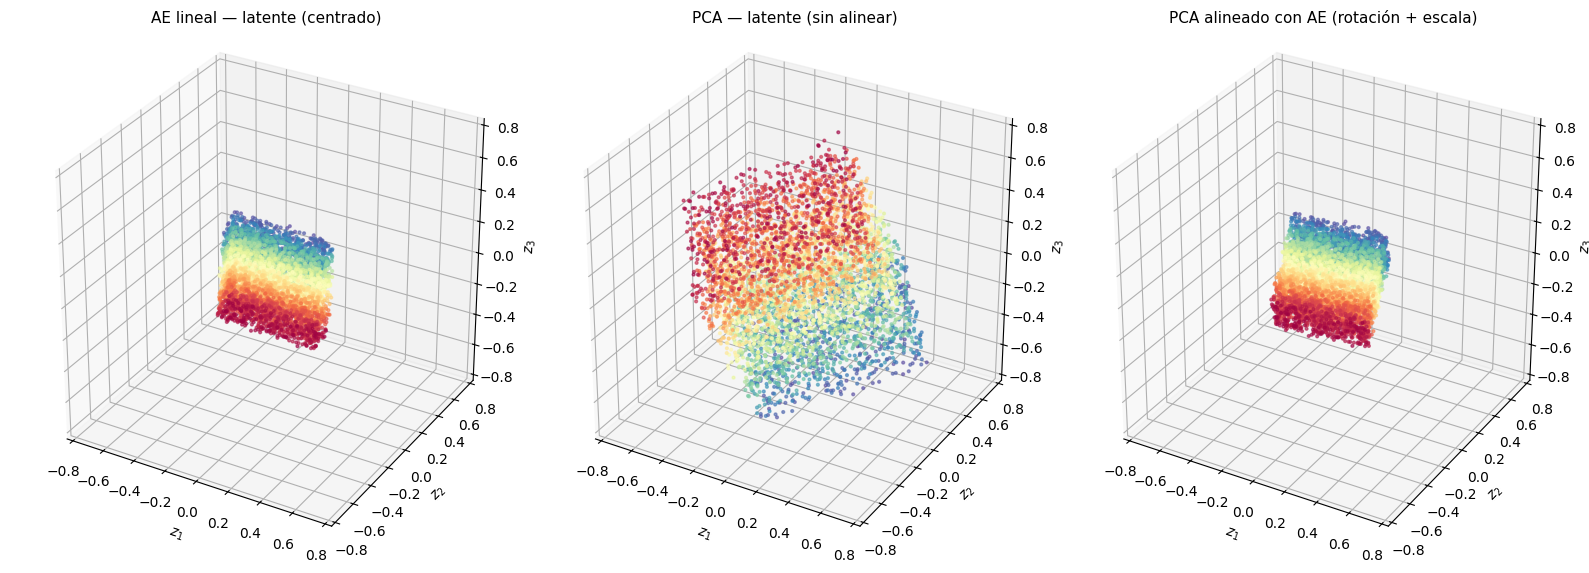

H_3,30 — escala uniforme óptima: 0.538
MSE residual tras alinear (centrado + rotación + escala): 0.001125  (4.5 % de la varianza del código del AE)
(un residuo pequeño confirma que ambos códigos describen la misma nube salvo un cambio de base del subespacio principal)


In [79]:
# Variedad lineal H_3,30 (d=3): AE lineal vs PCA vs PCA alineado, en 3D.
ds, meta, X = DATA["linear"]
d = get_latent_dim("linear")
z_ae = LATENT["linear"]["linear_AE"]

pca_lin = PCA(n_components=d)
z_pca = pca_lin.fit_transform(X)

# Mismo alineamiento que en el Swiss Roll: centrado + rotación + escala.
z_ae_c  = z_ae - z_ae.mean(axis=0)
z_pca_c = z_pca - z_pca.mean(axis=0)
R, _ = orthogonal_procrustes(z_pca_c, z_ae_c)
z_rot = z_pca_c @ R
scale = float(np.sum(z_rot * z_ae_c) / np.sum(z_rot ** 2))
z_pca_aligned = z_rot * scale

if d < 3:
    print(f"d={d} < 3: se omite el scatter 3D (el latente no tiene tres coordenadas).")
else:
    panels = [(z_ae_c,        "AE lineal — latente (centrado)"),
              (z_pca_c,       "PCA — latente (sin alinear)"),
              (z_pca_aligned, "PCA alineado con AE (rotación + escala)")]

    # Mismos límites en los tres ejes y en los tres paneles, con box_aspect
    # cúbico: la escala de los ejes es idéntica en los tres.
    lo = min(float(z[:, :3].min()) for z, _ in panels)
    hi = max(float(z[:, :3].max()) for z, _ in panels)
    pad = 0.05 * (hi - lo)

    fig = plt.figure(figsize=(16, 5.5))
    for i, (z, title) in enumerate(panels, start=1):
        ax = fig.add_subplot(1, 3, i, projection="3d")
        ax.scatter(z[:, 0], z[:, 1], z[:, 2], c=ds.labels, cmap="Spectral", s=4, alpha=0.6)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.set_zlabel("$z_3$")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_zlim(lo - pad, hi + pad)
        ax.set_box_aspect((1, 1, 1))

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "step4_ae_vs_pca_latent_linear3d.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

resid_mse_lin = float(np.mean((z_pca_aligned - z_ae_c) ** 2))
var_ae_lin    = float(np.mean(z_ae_c ** 2))
print(f"H_3,30 — escala uniforme óptima: {scale:.3f}")
print(f"MSE residual tras alinear (centrado + rotación + escala): {resid_mse_lin:.6f}  "
      f"({100 * resid_mse_lin / var_ae_lin:.1f} % de la varianza del código del AE)")
print("(un residuo pequeño confirma que ambos códigos describen la misma nube "
      "salvo un cambio de base del subespacio principal)")

---
## Paso 5 — Autoencoder no lineal y sus límites

Entrenamos el autoencoder estándar (**con** no linealidades ReLU) sobre los
mismos datasets y dimensión, y aplicamos dos diagnósticos:

- **Diagnóstico 1 — huecos en el latente.** Muestreamos puntos latentes
  *entre* los códigos de entrenamiento (puntos medios de pares aleatorios) y
  los decodificamos; medimos la distancia de las decodificaciones a la variedad
  real (vecino más cercano en el espacio de datos). Un cociente
  `hueco / reconstrucción-real` grande indica que el decoder inventa puntos
  fuera de la variedad.
- **Diagnóstico 2 — sensibilidad.** Perturbamos las entradas con ruido
  gaussiano pequeño y medimos el crecimiento del error de reconstrucción y el
  **factor de amplificación** (desplazamiento del código latente / magnitud de
  la perturbación).

In [ ]:
print(f"{'dataset':11s} {'d':>2s} {'MSE':>8s} {'huecos(ratio)':>14s} "
      f"{'sens.MSE+':>10s} {'amplif':>7s}")
for name, spec in SPECS.items():
    ds, meta, X = DATA[name]
    d = get_latent_dim(name)
    set_seed(SEED)
    model = build_dae(meta["ambient_dim"], latent_dim=d)   # AE no lineal (sin ruido)
    losses = train_model(model, ds, dae_loss, noise_fn=None,
                         epochs=EPOCHS, lr=LR, device=DEVICE, seed=SEED,
                         desc=f"{name} · nonlinear_AE")
    LOSSES[name]["nonlinear_AE"] = losses
    z = get_latent(model, ds, device=DEVICE)
    TRAINED[name]["nonlinear_AE"] = model
    LATENT[name]["nonlinear_AE"]  = z
    hole = latent_hole_probe(model, z, X, n_probes=200, mode="interpolation", seed=SEED)
    sens = noise_sensitivity(model, X, sigma=0.1, seed=SEED)
    print(f"{name:11s} {d:>2d} {losses[-1]:>8.4f} {hole['ratio']:>14.2f} "
          f"{sens['mse_increase']:>10.4f} {sens['amplification']:>7.3f}")

In [ ]:
# Curvas de pérdida del AE no lineal (una por dataset).
fig, axes = plt.subplots(1, len(SPECS), figsize=(6 * len(SPECS), 4))
for ax, name in zip(np.atleast_1d(axes), SPECS):
    ax.plot(LOSSES[name]["nonlinear_AE"])
    ax.set_title(f"{name} — AE no lineal"); ax.set_xlabel("época"); ax.set_ylabel("loss (MSE)")
    ax.set_yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step5_loss_curves_nonlinear_AE.png"), dpi=150, bbox_inches="tight")
plt.show()

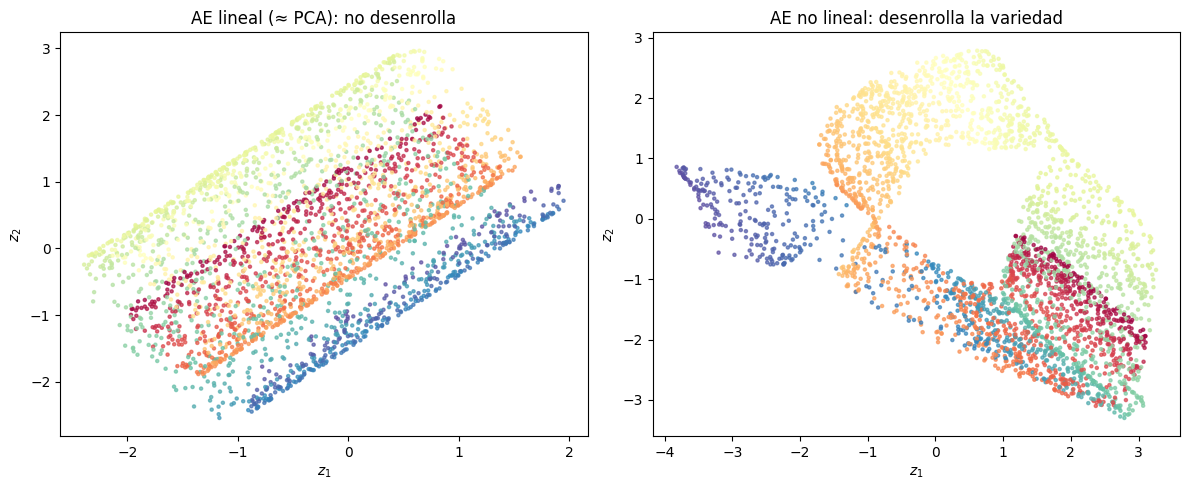

In [81]:
# Swiss Roll: comparación visual PCA (lineal) vs AE no lineal (2D).
ds, meta, X = DATA["swiss_roll"]
z_lin = LATENT["swiss_roll"]["linear_AE"]
z_nl  = LATENT["swiss_roll"]["nonlinear_AE"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
a1.scatter(z_lin[:, 0], z_lin[:, 1], c=ds.labels, cmap="Spectral", s=5, alpha=0.7)
a1.set_title("AE lineal (≈ PCA): no desenrolla"); a1.set_xlabel("$z_1$"); a1.set_ylabel("$z_2$")
a2.scatter(z_nl[:, 0], z_nl[:, 1], c=ds.labels, cmap="Spectral", s=5, alpha=0.7)
a2.set_title("AE no lineal: desenrolla la variedad"); a2.set_xlabel("$z_1$"); a2.set_ylabel("$z_2$")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step5_linear_vs_nonlinear.png"), dpi=150, bbox_inches="tight")
plt.show()

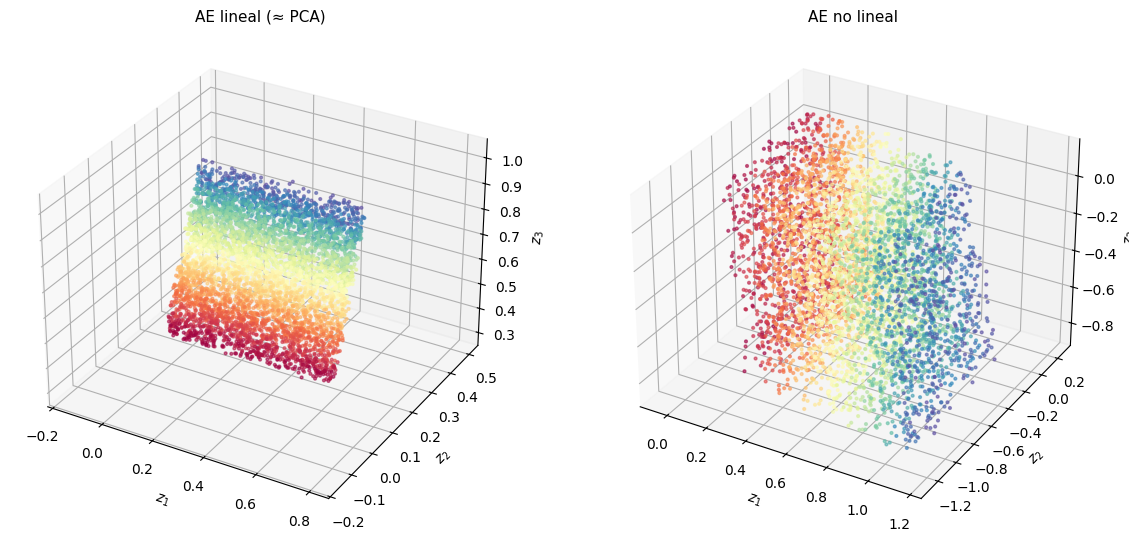

In [82]:
# Variedad lineal H_3,30: comparación visual AE lineal (≈ PCA) vs AE no
# lineal, en 3D. A diferencia del Swiss Roll, aquí la variedad ya es lineal,
# así que no hay nada que "desenrollar": se espera que ambos latentes
# describan la misma nube (salvo cambio de base), sin la mejora que el AE
# no lineal aporta en el Swiss Roll.
ds, meta, X = DATA["linear"]
d = get_latent_dim("linear")
z_lin = LATENT["linear"]["linear_AE"]
z_nl  = LATENT["linear"]["nonlinear_AE"]

if d < 3:
    print(f"d={d} < 3: se omite el scatter 3D (el latente no tiene tres coordenadas).")
else:
    fig = plt.figure(figsize=(12, 5.5))
    panels = [(z_lin, "AE lineal (≈ PCA)"), (z_nl, "AE no lineal")]
    for i, (z, title) in enumerate(panels, start=1):
        ax = fig.add_subplot(1, 2, i, projection="3d")
        ax.scatter(z[:, 0], z[:, 1], z[:, 2], c=ds.labels, cmap="Spectral", s=4, alpha=0.6)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.set_zlabel("$z_3$")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "step5_linear_vs_nonlinear_linear3d.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

---
## Paso 6 — VAE y DAE

**VAE.** Encoder que produce $(\mu,\sigma)$, reparametrización estándar y
pérdida
$$\mathcal{L} = \alpha\,\mathbb{E}\!\left[\|x - g(z)\|^2\right] + \beta\,\mathrm{KL}\!\left(q(z\mid x)\,\|\,\mathcal N(0,I)\right),$$
con $\alpha = 1/(2\gamma)$ ($\gamma$ hiperparámetro fijo, no aprendido) y la KL
en forma cerrada. Se usa $\gamma$ pequeño para que la reconstrucción no colapse
(un $\gamma$ demasiado grande provoca *posterior collapse*); $\beta$ queda como
parámetro fácil de variar.

**DAE.** Corrupción gaussiana $\tilde x = x + \varepsilon$,
$\varepsilon\sim\mathcal N(0,\sigma^2 I)$, y pérdida $\|x - g(f(\tilde x))\|^2$
(el objetivo es $x$ **limpio**).

Repetimos sobre ambos los **dos diagnósticos** del Paso 5.

> **Nivel de ruido del DAE — *placeholder*.** Fijamos $\sigma$ con una
> heurística provisional: una fracción pequeña (10 %) de la mediana de la
> distancia al $k$-ésimo vecino más cercano de los datos de entrenamiento
> (`suggest_dae_sigma`). Este valor es un **marcador de posición** pendiente de
> una justificación teórica formal —ligada al *reach* de la variedad— que se
> desarrolla en el capítulo de metodología de la tesis.

In [ ]:
print(f"{'dataset':11s} {'modelo':6s} {'d':>2s} {'MSE':>8s} {'huecos':>8s} "
      f"{'amplif':>7s} {'sigma':>8s}")
for name, spec in SPECS.items():
    ds, meta, X = DATA[name]
    d = get_latent_dim(name)

    # VAE (formulación gamma/beta)
    set_seed(SEED)
    vae = build_vae(meta["ambient_dim"], latent_dim=d, beta=BETA)
    vae_fn = lambda x, out: vae_loss_gamma(x, out, gamma=GAMMA, beta=BETA)
    losses_vae = train_model(vae, ds, vae_fn, noise_fn=None, epochs=EPOCHS, lr=LR,
                device=DEVICE, seed=SEED, desc=f"{name} · VAE")
    LOSSES[name]["VAE"] = losses_vae
    z_vae = get_latent(vae, ds, device=DEVICE)
    TRAINED[name]["VAE"] = vae; LATENT[name]["VAE"] = z_vae

    # DAE (sigma heurística)
    sigma = suggest_dae_sigma(X, k=DAE_SIGMA_K, fraction=DAE_SIGMA_FRACTION)
    set_seed(SEED)
    dae = build_dae(meta["ambient_dim"], latent_dim=d)
    losses_dae = train_model(dae, ds, dae_loss, noise_fn=get_noise_fn("gaussian", sigma=sigma),
                epochs=EPOCHS, lr=LR, device=DEVICE, seed=SEED, desc=f"{name} · DAE")
    LOSSES[name]["DAE"] = losses_dae
    z_dae = get_latent(dae, ds, device=DEVICE)
    TRAINED[name]["DAE"] = dae; LATENT[name]["DAE"] = z_dae

    for tag, m, z in [("VAE", vae, z_vae), ("DAE", dae, z_dae)]:
        hole = latent_hole_probe(m, z, X, n_probes=200, seed=SEED)
        sens = noise_sensitivity(m, X, sigma=0.1, seed=SEED)
        sig = sigma if tag == "DAE" else float("nan")
        print(f"{name:11s} {tag:6s} {d:>2d} {sens['mse_clean']:>8.4f} "
              f"{hole['ratio']:>8.2f} {sens['amplification']:>7.3f} {sig:>8.4f}")

In [ ]:
# Curvas de pérdida de VAE y DAE (una por dataset). Nota: la pérdida del
# VAE incluye el término KL además de la reconstrucción, así que su escala
# no es directamente comparable a la del DAE (MSE puro) -- lo relevante
# aquí es si CADA curva se ha aplanado, no comparar sus valores absolutos.
fig, axes = plt.subplots(1, len(SPECS), figsize=(6 * len(SPECS), 4))
for ax, name in zip(np.atleast_1d(axes), SPECS):
    ax.plot(LOSSES[name]["VAE"], label="VAE (recon + KL)")
    ax.plot(LOSSES[name]["DAE"], label="DAE (MSE)")
    ax.set_title(f"{name} — VAE vs DAE"); ax.set_xlabel("época"); ax.set_ylabel("loss")
    ax.set_yscale("log"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step6_loss_curves_vae_dae.png"), dpi=150, bbox_inches="tight")
plt.show()

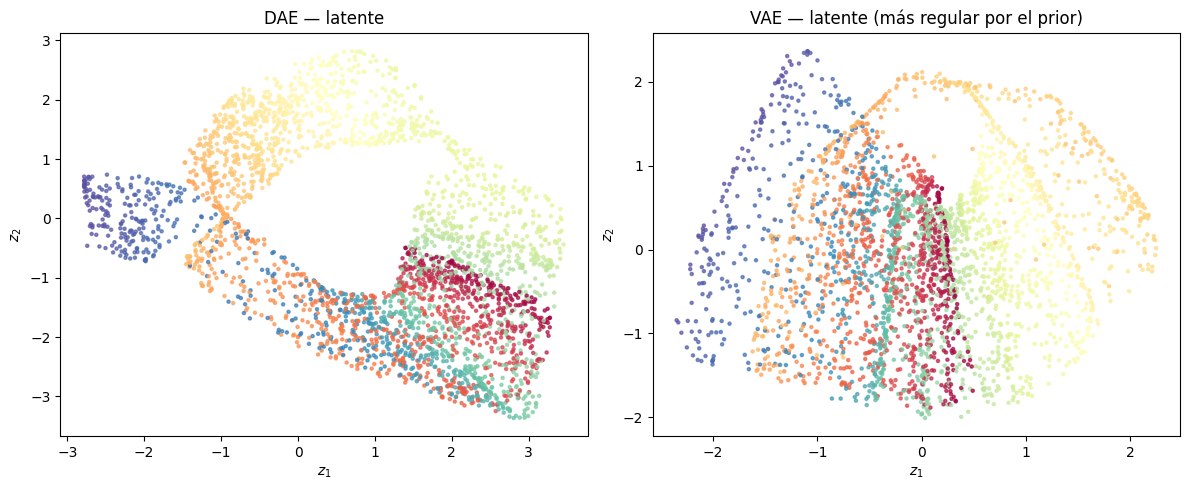

In [84]:
# Swiss Roll: espacios latentes DAE vs VAE.
ds, meta, X = DATA["swiss_roll"]
z_dae = LATENT["swiss_roll"]["DAE"]; z_vae = LATENT["swiss_roll"]["VAE"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
a1.scatter(z_dae[:, 0], z_dae[:, 1], c=ds.labels, cmap="Spectral", s=5, alpha=0.7)
a1.set_title("DAE — latente"); a1.set_xlabel("$z_1$"); a1.set_ylabel("$z_2$")
a2.scatter(z_vae[:, 0], z_vae[:, 1], c=ds.labels, cmap="Spectral", s=5, alpha=0.7)
a2.set_title("VAE — latente (más regular por el prior)"); a2.set_xlabel("$z_1$"); a2.set_ylabel("$z_2$")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step6_dae_vs_vae.png"), dpi=150, bbox_inches="tight")
plt.show()

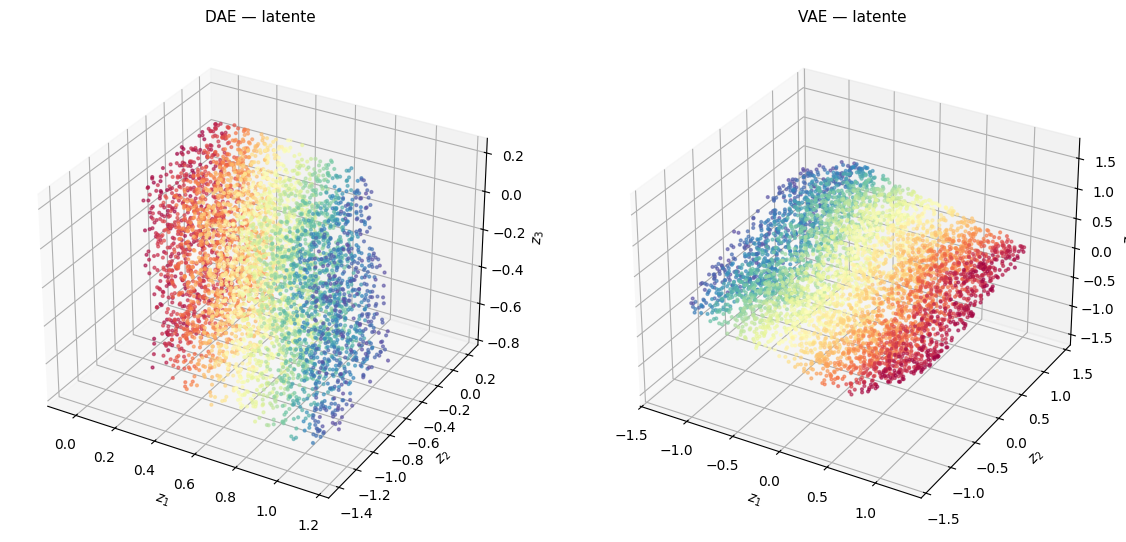

In [85]:
# Variedad lineal H_3,30: espacios latentes DAE vs VAE, en 3D. Igual que en
# el panel anterior, se espera que ambos coincidan sustancialmente con el AE
# lineal/PCA: sobre una variedad lineal, la no linealidad de los modelos no
# aporta ventaja.
ds, meta, X = DATA["linear"]
d = get_latent_dim("linear")
z_dae = LATENT["linear"]["DAE"]; z_vae = LATENT["linear"]["VAE"]

if d < 3:
    print(f"d={d} < 3: se omite el scatter 3D (el latente no tiene tres coordenadas).")
else:
    fig = plt.figure(figsize=(12, 5.5))
    panels = [(z_dae, "DAE — latente"), (z_vae, "VAE — latente")]
    for i, (z, title) in enumerate(panels, start=1):
        ax = fig.add_subplot(1, 2, i, projection="3d")
        ax.scatter(z[:, 0], z[:, 1], z[:, 2], c=ds.labels, cmap="Spectral", s=4, alpha=0.6)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.set_zlabel("$z_3$")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "step6_dae_vs_vae_linear3d.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

---
## Paso 7 — Segunda estimación de dimensión desde el modelo

Aplicamos el estimador de **dimensión efectiva vía jacobiano** (Paso 1) sobre
los **decoders entrenados** de VAE y DAE, evaluándolo en los códigos latentes
de entrenamiento, y lo comparamos con la estimación *data-driven* del Paso 3.
Una coincidencia refuerza que la variedad aprendida tiene la dimensión correcta.

In [86]:
cfg = load_experiment_config()
print(f"{'dataset':11s} {'geom-prob (P3)':>15s} {'DAE jac (P7)':>13s} {'VAE jac (P7)':>13s}")
for name in SPECS:
    ds, meta, X = DATA[name]
    z_dae = torch.tensor(LATENT[name]["DAE"], dtype=torch.float32)
    z_vae = torch.tensor(LATENT[name]["VAE"], dtype=torch.float32)
    idx = np.random.RandomState(SEED).choice(len(z_dae), size=min(200, len(z_dae)), replace=False)
    jd = effective_dimension_jacobian(TRAINED[name]["DAE"].decode, z_dae[idx], rel_threshold=0.01)
    jv = effective_dimension_jacobian(TRAINED[name]["VAE"].decode, z_vae[idx], rel_threshold=0.01)
    print(f"{name:11s} {cfg[name]['estimates']['geometric_prob']:>15d} "
          f"{jd['effective_dim']:>13.2f} {jv['effective_dim']:>13.2f}")

dataset      geom-prob (P3)  DAE jac (P7)  VAE jac (P7)
swiss_roll                2          2.00          2.00
linear                    3          3.00          3.00


---
## Paso 8 — Comparación final (Swiss Roll + lineal)

Construimos una **tabla única** con todas las métricas comunes para los cuatro
modelos (AE lineal, AE no lineal, VAE, DAE) sobre los dos datasets sintéticos,
y la guardamos como CSV en `results/`. Las métricas de topología se calculan
sobre un submuestreo (≤ 1500 puntos) porque *continuity* es $O(N^2)$. Las
filas de COIL-20 (un objeto) se añaden a esta misma tabla más adelante, en el
Paso 11; el Paso 10 (MNIST **completo**) no entra en ella, porque allí no hay
una variedad única que comparar y solo se entrena un AE no lineal.

In [87]:
import csv
cfg = load_experiment_config()
rows = []
for name in SPECS:
    ds, meta, X = DATA[name]
    d = get_latent_dim(name)
    for model_name in ["linear_AE", "nonlinear_AE", "VAE", "DAE"]:
        model = TRAINED[name][model_name]
        z = LATENT[name][model_name]
        met = evaluate_common_metrics(model, X, z, n_neighbors=12,
                                      jacobian_points=200, topo_max_points=1500,
                                      device=DEVICE, seed=SEED)
        rows.append({"dataset": name, "model": model_name, "latent_dim": d,
                     "expected_dim": meta["expected_intrinsic_dim"],
                     "geo_prob_dim": cfg[name]["estimates"]["geometric_prob"],
                     "mse": round(met["mse"], 4),
                     "trustworthiness": round(met["trustworthiness"], 4),
                     "continuity": round(met["continuity"], 4),
                     "jacobian_dim": round(met["jacobian_dim"], 2)})

out_csv = os.path.join("results", "comparison_table.csv")
with open(out_csv, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    w.writeheader(); w.writerows(rows)
print("Tabla guardada en", out_csv, "\n")

# Impresión legible
hdr = ["dataset", "model", "mse", "trustworthiness", "continuity", "jacobian_dim"]
print(f"{hdr[0]:11s} {hdr[1]:13s} {hdr[2]:>8s} {hdr[3]:>14s} {hdr[4]:>10s} {hdr[5]:>12s}")
for r in rows:
    print(f"{r['dataset']:11s} {r['model']:13s} {r['mse']:>8.4f} "
          f"{r['trustworthiness']:>14.4f} {r['continuity']:>10.4f} {r['jacobian_dim']:>12.2f}")

Tabla guardada en results\comparison_table.csv 

dataset     model              mse trustworthiness continuity jacobian_dim
swiss_roll  linear_AE       0.2996         0.8570     0.9919         2.00
swiss_roll  nonlinear_AE    0.0480         0.9798     0.9897         2.00
swiss_roll  VAE             0.0642         0.9756     0.9883         2.00
swiss_roll  DAE             0.0478         0.9805     0.9904         2.00
linear      linear_AE       0.0000         0.9995     0.9994         3.00
linear      nonlinear_AE    0.0000         0.9996     0.9994         3.00
linear      VAE             0.0020         0.9998     0.9998         3.00
linear      DAE             0.0000         0.9994     0.9991         3.00


### Discusión (Swiss Roll + lineal)

- **Swiss Roll (variedad no lineal).** El AE lineal (≈ PCA) no desenrolla la
  lámina y su *trustworthiness* es netamente inferior. Los tres modelos no
  lineales recuperan la estructura 2D; **DAE y AE no lineal** logran el mejor
  MSE, mientras que el **VAE** sacrifica algo de reconstrucción a cambio de un
  latente más regular (menos huecos), como muestra el diagnóstico del Paso 6.
- **$H_{3,30}$ (variedad lineal).** Todos los modelos reconstruyen casi
  perfectamente y las métricas de topología son $\approx 1$: cuando la variedad
  es lineal, la no linealidad no aporta y todos coinciden con PCA.

En conjunto, los resultados sostienen la tesis en el caso de variedades
únicas y conexas: los autoencoders no lineales —y en particular VAE y DAE—
aprenden la variedad subyacente y reducen la dimensión de forma coherente con
la dimensión intrínseca estimada de los datos. Los Pasos 9-11 extienden el
análisis a datos reales (MNIST, COIL-20), donde el dataset completo es una
**unión** de variedades: en el Paso 10 estudiamos MNIST completo tal cual,
para ver si el latente separa las clases, y en el Paso 11 aislamos un solo
objeto de COIL-20 para poder repetir el esquema entero.

> **Pendiente.** Justificación teórica del $\sigma$ del DAE (vía *reach*), y
> repetición con varias semillas.

---
## Paso 9 — Datasets múltiples: por qué se tratan aparte

Swiss Roll y la variedad lineal $H_{3,30}$ (Pasos 1-8) son cada uno **una
única variedad conexa**: "la dimensión intrínseca del dataset" es una
pregunta bien planteada, y los tres estimadores del Paso 3 la responden con
sentido.

**MNIST completo** (10 clases de dígito) y **COIL-20 completo** (20 objetos
rotando) son distintos por naturaleza: cada uno es la **unión de varias
variedades independientes**, no una sola variedad conexa. Aplicar el mismo
estimador de dimensión directamente sobre la unión mezcla dos cosas: la
dimensión intrínseca de cada sub-variedad (el estilo de trazo dentro de un
dígito, el giro de un objeto) y los grados de libertad "extra" que hacen
falta para separar las $k$ componentes entre sí — a qué clase u objeto
pertenece cada punto. Con vecinos-más-cercanos o conteo de cajas, esa
separación entre componentes se cuenta como dimensión adicional, así que el
estimador **sobreestima sistemáticamente** frente a la dimensión de
cualquiera de las sub-variedades por separado.

Ante esto hay dos respuestas complementarias, y el notebook usa una en cada
dataset:

- **MNIST (Paso 10): estudiarlo completo, a propósito.** No aislamos ningún
  dígito. Estimamos la dimensión sobre la mezcla de las 10 clases sabiendo
  que saldrá **inflada** por el argumento anterior, entrenamos un AE no
  lineal con esa dimensión y miramos el espacio latente coloreado por clase.
  La pregunta ya no es "¿cuál es la dimensión intrínseca de MNIST?" —que,
  como acabamos de argumentar, no está bien planteada— sino si el
  autoencoder es capaz de **separar las diez clases** en su espacio latente
  pese a entrenarse sin etiquetas y con una $d$ que mezcla estilo de trazo y
  separación entre dígitos.
- **COIL-20 (Paso 11): aislar una sola componente.** Aquí sí nos quedamos con
  un único objeto antes de estimar: la variedad vuelve a ser única y conexa,
  y se puede repetir el esquema completo de los Pasos 3-8 (estimar $d$,
  entrenar los cuatro modelos con esa $d$, comparar métricas) con garantías.
  Es especialmente ilustrativo porque un solo objeto rotando es, por
  construcción, un giro puro — topológicamente una circunferencia $S^1$ —
  así que su dimensión intrínseca **debería** salir mucho más baja que la del
  dataset completo, y el espacio latente entrenado con esa $d$ debería poder
  visualizarse como tal.

---
## Paso 10 — MNIST completo: ¿separa el latente las diez clases?

A diferencia del Paso 11, aquí **no aislamos ningún dígito**: cargamos MNIST
**completo** con `get_dataset_with_meta("mnist", n_samples=...)` (~3000
muestras, el mismo orden de submuestreo que el resto del notebook), es decir,
la **mezcla de las 10 clases**. Es una decisión deliberada: por el argumento
del Paso 9 la dimensión estimada sobre una unión de variedades queda
**inflada** —cuenta a la vez el estilo de trazo dentro de cada dígito y los
grados de libertad que separan unas clases de otras—, y precisamente eso es
lo que queremos poner a prueba.

El flujo tiene tres partes:

1. **Estimar la dimensión** con el método geométrico-probabilístico
   (`estimate_dimension`, con un rango de candidatos amplio, hasta $n=15$) y
   con PCA95 (`estimate_dimension_pca`). **Minkowski se omite**: en $D=784$
   el conteo de cajas degenera —cada punto acaba en su propia caja y no hay
   régimen de escala lineal—, la misma limitación documentada en el Paso 3 y
   en el Paso 11; se deja fuera en vez de arrastrar un número sin sentido. La
   $d$ elegida (`choose_latent_dim`, regla: geométrico-probabilístico) se
   guarda en `results/experiment_config.json` bajo la clave `"mnist"`.
2. **Entrenar un único AE no lineal** (`build_dae`, con no linealidades ReLU
   — no el lineal) con esa $d$ y los mismos hiperparámetros globales
   (`EPOCHS`, `LR`, `SEED`, `DEVICE`) que el resto del notebook.
3. **Visualizar el espacio latente** coloreado por dígito. Si cada clase
   ocupa una región propia, el autoencoder ha separado las diez variedades
   sin haber visto ni una etiqueta — pese a que la $d$ con la que se entrenó
   proviene de una estimación inflada por esa misma mezcla.

Este paso **no** añade filas a `results/comparison_table.csv` (esa tabla
compara los cuatro modelos sobre variedades únicas) ni entrena VAE/DAE/AE
lineal: aquí solo interesan la estimación de dimensión y la visualización.

In [ ]:
# MNIST completo (mezcla de las 10 clases), mismo orden de submuestreo que
# el resto del notebook. Aquí `ds.labels` SÍ son las etiquetas de dígito
# (0-9), a diferencia del dataset "mnist_digit" (ver data/datasets.py).
MNIST_N_SAMPLES = 3000

ds_mn, meta_mn = get_dataset_with_meta("mnist", n_samples=MNIST_N_SAMPLES)
X_mn = ds_mn.data.numpy()
DATA["mnist"]    = (ds_mn, meta_mn, X_mn)
TRAINED["mnist"] = {}
LATENT["mnist"]  = {}
LOSSES["mnist"]  = {}

counts = np.bincount(ds_mn.labels.astype(int), minlength=10)
print(f"mnist  data={tuple(ds_mn.data.shape)}  ambient_dim={meta_mn['ambient_dim']}  "
      f"dim_esperada={meta_mn['expected_intrinsic_dim']}")
print("muestras por dígito:", "  ".join(f"{k}:{c}" for k, c in enumerate(counts)))

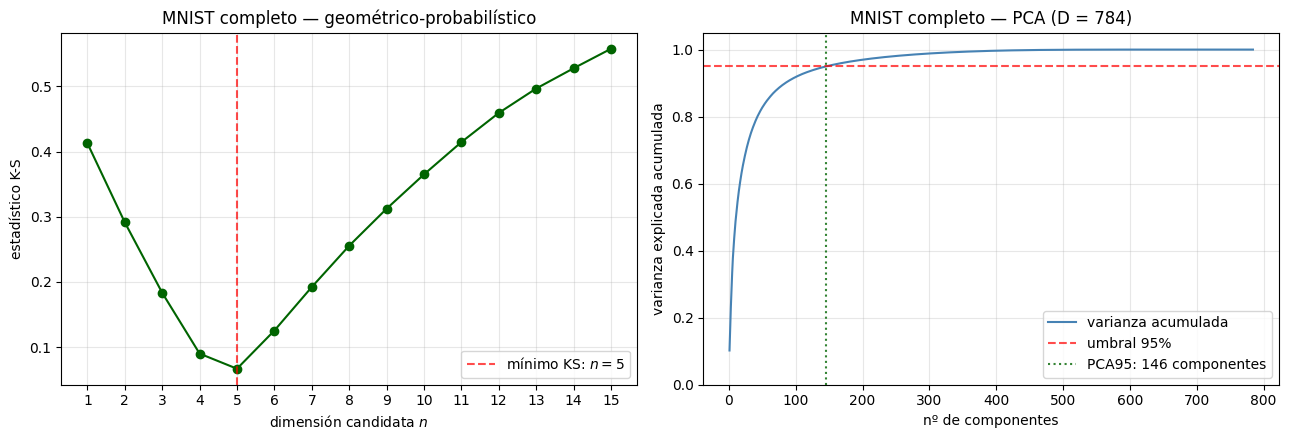

dataset  esperada  GeomProb  PCA95  PCA-PR  -> d
mnist          12         5    146   30.29     5


In [89]:
# Paso 3 (MNIST completo): geométrico-probabilístico + PCA95. Minkowski se
# omite a propósito -- en D=784 el conteo de cajas degenera (cada punto en su
# propia caja, sin régimen de escala lineal), igual que se documenta para
# COIL-20 en el Paso 11. La d elegida es la de Ivanov, vía choose_latent_dim.
from dimension_estimation.geometric_prob import estimate_dimension
from dimension_estimation.pca import estimate_dimension_pca

MNIST_N_MAX = 15   # rango de candidatos amplio: se espera una d inflada

ds, meta, X = DATA["mnist"]
geo, geo_res = estimate_dimension(X, n_min=1, n_max=MNIST_N_MAX)
pca_res = estimate_dimension_pca(X, threshold=0.95)

est = {
    "minkowski": float("nan"),   # omitido: degenera en D=784
    "geometric_prob": int(geo),
    "pca_threshold": int(pca_res["variance_threshold_dim"]),
    "pca_participation": float(pca_res["participation_ratio_dim"]),
    "geometric_prob_ks": [float(v) for v in geo_res["ks_vals"]],
}
d = choose_latent_dim(est, expected=meta["expected_intrinsic_dim"])

cfg = load_experiment_config()
cfg["mnist"] = {"ambient_dim": meta["ambient_dim"],
                "expected_intrinsic_dim": meta["expected_intrinsic_dim"],
                "estimates": est, "latent_dim": d}
save_experiment_config(cfg)

cand = geo_res["candidates"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))

a1.plot(cand, geo_res["ks_vals"], "o-", color="darkgreen", markersize=6)
a1.axvline(geo, color="red", linestyle="--", alpha=0.7, label=f"mínimo KS: $n = {geo}$")
a1.set_xlabel("dimensión candidata $n$"); a1.set_ylabel("estadístico K-S")
a1.set_title("MNIST completo — geométrico-probabilístico")
a1.set_xticks(cand); a1.legend(); a1.grid(True, alpha=0.3)

cum = pca_res["cumulative_variance"]
k = np.arange(1, len(cum) + 1)
k95 = pca_res["variance_threshold_dim"]
a2.plot(k, cum, "-", color="steelblue", label="varianza acumulada")
a2.axhline(pca_res["threshold"], color="red", linestyle="--", alpha=0.7,
           label=f"umbral {pca_res['threshold']:.0%}")
a2.axvline(k95, color="darkgreen", linestyle=":", alpha=0.8,
           label=f"PCA95: {k95} componentes")
a2.set_xlabel("nº de componentes"); a2.set_ylabel("varianza explicada acumulada")
a2.set_title(f"MNIST completo — PCA (D = {meta['ambient_dim']})")
a2.set_ylim(0, 1.05); a2.legend(loc="lower right"); a2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step10_mnist_dimension.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"{'dataset':8s} {'esperada':>8s} {'GeomProb':>9s} {'PCA95':>6s} "
      f"{'PCA-PR':>7s} {'-> d':>5s}")
print(f"{'mnist':8s} {str(meta['expected_intrinsic_dim']):>8s} "
      f"{est['geometric_prob']:>9d} {est['pca_threshold']:>6d} "
      f"{est['pca_participation']:>7.2f} {d:>5d}")
if geo >= max(cand):
    print(f"\nNota: el geométrico-probabilístico eligió el candidato más alto probado "
          f"(n_max={MNIST_N_MAX}); podría estar tocando el techo del rango.")

In [ ]:
# Paso 5 (MNIST completo): UN solo modelo, el AE no lineal (ReLU, sin ruido),
# con la d de Ivanov y los hiperparámetros globales del notebook.
ds, meta, X = DATA["mnist"]
d = get_latent_dim("mnist")

set_seed(SEED)
mnist_ae = build_dae(meta["ambient_dim"], latent_dim=d)
losses = train_model(mnist_ae, ds, dae_loss, noise_fn=None,
                     epochs=EPOCHS, lr=LR, device=DEVICE, seed=SEED,
                     desc="mnist · nonlinear_AE")
LOSSES["mnist"]["nonlinear_AE"] = losses
TRAINED["mnist"]["nonlinear_AE"] = mnist_ae
LATENT["mnist"]["nonlinear_AE"]  = get_latent(mnist_ae, ds, device=DEVICE)

print(f"mnist  d={d}  AE no lineal entrenado ({EPOCHS} épocas)  "
      f"MSE final={losses[-1]:.4f}")

In [ ]:
# Curva de pérdida del AE no lineal sobre MNIST completo.
plt.figure(figsize=(6, 4))
plt.plot(LOSSES["mnist"]["nonlinear_AE"])
plt.title("MNIST completo — AE no lineal: curva de pérdida")
plt.xlabel("época"); plt.ylabel("loss (MSE)"); plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step10_loss_curve_mnist.png"), dpi=150, bbox_inches="tight")
plt.show()

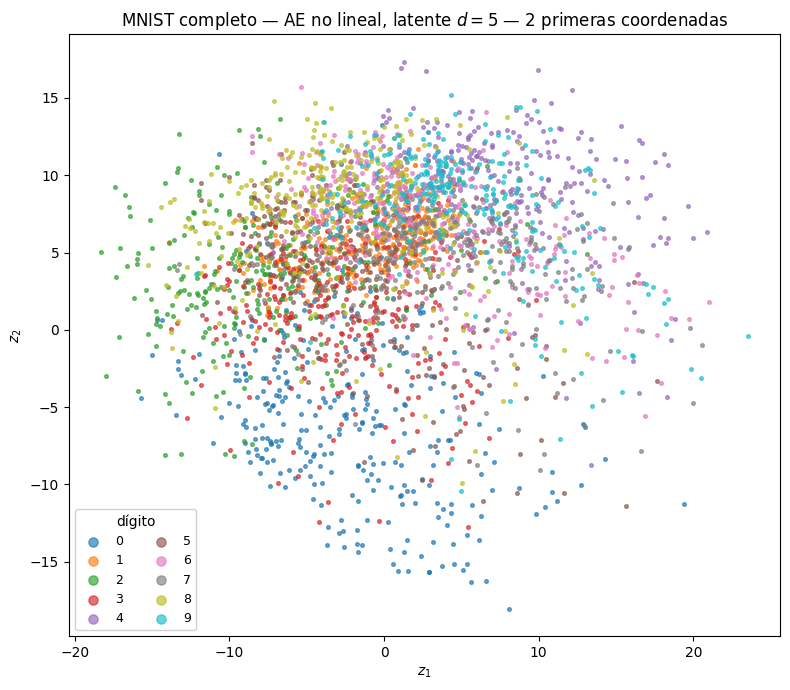

d=5: dimensión estimada por el geométrico-probabilístico sobre la mezcla de las 10 clases (inflada, ver Paso 9).
El gráfico muestra solo las 2 primeras coordenadas de un latente 5-dimensional: un solapamiento parcial entre dígitos en el plano no implica que no estén separados en las 5 dimensiones completas.


In [91]:
# MNIST completo: espacio latente del AE no lineal coloreado por dígito
# (10 colores discretos, colormap categórico "tab10"). Si el AE ha separado
# las diez variedades, cada color ocupará su propia región del plano.
ds, meta, X = DATA["mnist"]
d = get_latent_dim("mnist")
z = LATENT["mnist"]["nonlinear_AE"]
digits = ds.labels.astype(int)

cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(8, 7))
for digit in range(10):
    m = digits == digit
    y_coord = z[m, 1] if d >= 2 else np.zeros(int(m.sum()))
    ax.scatter(z[m, 0], y_coord, color=cmap(digit), s=7, alpha=0.65, label=str(digit))

ax.set_xlabel("$z_1$")
if d >= 2:
    ax.set_ylabel("$z_2$")
else:
    ax.set_yticks([])
proj = " — 2 primeras coordenadas" if d > 2 else ""
ax.set_title(f"MNIST completo — AE no lineal, latente $d={d}${proj}")
ax.legend(title="dígito", markerscale=2.5, ncol=2, fontsize=9,
          loc="best", framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step10_mnist_latent_by_digit.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print(f"d={d}: dimensión estimada por el geométrico-probabilístico sobre la mezcla "
      f"de las 10 clases (inflada, ver Paso 9).")
if d > 2:
    print(f"El gráfico muestra solo las 2 primeras coordenadas de un latente "
          f"{d}-dimensional: un solapamiento parcial entre dígitos en el plano no "
          f"implica que no estén separados en las {d} dimensiones completas.")

---
## Paso 11 — COIL-20: un solo objeto

**COIL-20** (Columbia Object Image Library) es un dataset **real** de
imágenes: 20 objetos fotografiados cada $5°$ de rotación completa (72
vistas/objeto, $128\times128$ px en gris → $1440$ imágenes, dimensión
ambiente $16384$). No tiene loader automático (no está en
`torchvision`/`sklearn`) y no se puede descargar desde este entorno:

> **Antes de ejecutar esta sección**, descarga la versión procesada
> `coil-20-proc` desde la página oficial —
> <https://www.cs.columbia.edu/CAVE/software/softlib/coil-20.php> — y
> descomprímela en `data/raw/coil-20-proc/` (mismo nivel que la caché de
> MNIST; ese directorio ya está en `.gitignore`, no se versiona).

Como se explica en el Paso 9, el dataset completo (20 objetos) es una unión
de 20 variedades de rotación independientes, así que estimar "su" dimensión
mezcla el giro con la separación entre objetos. Aquí aislamos **un solo
objeto** (`get_dataset("coil20_object", object_id=...)`): sus 72 vistas
forman, por construcción, un giro puro — una variedad topológicamente
equivalente a una circunferencia $S^1$. Le damos al geométrico-probabilístico
un rango de candidatos generoso (no artificialmente corto) y dejamos que el
dato hable: estimamos $d$ y entrenamos los cuatro modelos con ese valor,
exactamente como en los Pasos 3-8. Si $d$ sale $\geq 2$, el espacio latente
debería poder visualizarse directamente como una circunferencia; si sale
$=1$, lo discutimos en la celda de visualización (un código real de una sola
coordenada no puede representar un lazo cerrado sin un "corte").

In [ ]:
COIL20_OBJECT_ID = 1  # objeto a analizar (1-20)

try:
    coil_ds, coil_meta = get_dataset_with_meta("coil20_object", object_id=COIL20_OBJECT_ID)
    coil_X = coil_ds.data.numpy()
    DATA["coil20_object"] = (coil_ds, coil_meta, coil_X)
    TRAINED["coil20_object"] = {}
    LATENT["coil20_object"]  = {}
    LOSSES["coil20_object"]  = {}
    print(f"coil20_object (obj. {COIL20_OBJECT_ID})  data={tuple(coil_ds.data.shape)}  "
          f"ambient_dim={coil_meta['ambient_dim']:4d}  "
          f"dim_esperada={coil_meta['expected_intrinsic_dim']}")
except FileNotFoundError as e:
    print(e)
    print("\nEl resto del Paso 11 se omite (celdas protegidas con "
          "`if \"coil20_object\" in DATA`) hasta que descargues los datos.")

In [93]:
# Paso 3 (COIL-20, un objeto): estimación y fijación de la dimensión latente.
#
# Con solo N=72 puntos en un espacio ambiente D=16384, el estimador de
# Minkowski (conteo de cajas) puede no encontrar ningún régimen de escala
# lineal válido y lanzar ValueError -- la misma degeneración en alta
# dimensión documentada para MNIST en el Paso 3, más aguda aquí por el
# tamaño de muestra. En vez de `estimate_all_dimensions` (que aborta si
# Minkowski falla), llamamos a los tres estimadores por separado y
# capturamos ese fallo puntual; la elección de d solo depende del
# geométrico-probabilístico, con un rango de candidatos amplio (n_max=10,
# no artificialmente corto) para dejar que el dato hable.
from dimension_estimation.minkowski import minkowski_dimension
from dimension_estimation.geometric_prob import estimate_dimension
from dimension_estimation.pca import estimate_dimension_pca

if "coil20_object" in DATA:
    ds, meta, X = DATA["coil20_object"]

    try:
        mink, _, _ = minkowski_dimension(X)
    except ValueError:
        mink = float("nan")
        print(f"Minkowski: régimen lineal no encontrado (N={len(X)} insuficiente "
              f"para D={meta['ambient_dim']}) -> NaN, se ignora en la elección de d.\n")

    geo, geo_res = estimate_dimension(X, n_min=1, n_max=10)
    pca_res = estimate_dimension_pca(X, threshold=0.95)
    est = {
        "minkowski": float(mink),
        "geometric_prob": int(geo),
        "pca_threshold": int(pca_res["variance_threshold_dim"]),
        "pca_participation": float(pca_res["participation_ratio_dim"]),
        "geometric_prob_ks": [float(v) for v in geo_res["ks_vals"]],
    }
    d = choose_latent_dim(est, expected=meta["expected_intrinsic_dim"])

    cfg = load_experiment_config()
    cfg["coil20_object"] = {"ambient_dim": meta["ambient_dim"],
                             "expected_intrinsic_dim": meta["expected_intrinsic_dim"],
                             "estimates": est, "latent_dim": d}
    save_experiment_config(cfg)

    print(f"{'dataset':13s} {'esperada':>8s} {'Minkowski':>10s} {'GeomProb':>9s} "
          f"{'PCA95':>6s} {'PCA-PR':>7s} {'-> d':>5s}")
    print(f"{'coil20_object':13s} {str(meta['expected_intrinsic_dim']):>8s} "
          f"{est['minkowski']:>10.2f} {est['geometric_prob']:>9d} "
          f"{est['pca_threshold']:>6d} {est['pca_participation']:>7.2f} {d:>5d}")
    if geo >= max(geo_res["candidates"]):
        print(f"\nNota: el geométrico-probabilístico eligió el candidato más alto "
              f"probado (n_max=10); podría estar tocando el techo del rango.")
else:
    print("Sin datos de COIL-20 cargados: se omite esta celda.")

Minkowski: régimen lineal no encontrado (N=71 insuficiente para D=16384) -> NaN, se ignora en la elección de d.

dataset       esperada  Minkowski  GeomProb  PCA95  PCA-PR  -> d
coil20_object        1        nan         5     14    4.23     5


In [ ]:
# Pasos 4-6 (COIL-20, un objeto): AE lineal vs PCA, AE no lineal, VAE y DAE.
if "coil20_object" in DATA:
    ds, meta, X = DATA["coil20_object"]
    d = get_latent_dim("coil20_object")

    # AE lineal vs PCA (ángulos principales)
    set_seed(SEED)
    lin = build_linear_ae(meta["ambient_dim"], latent_dim=d)
    losses_lin = train_model(lin, ds, dae_loss, epochs=EPOCHS, lr=5e-3, device=DEVICE, seed=SEED,
                desc="coil20_object · linear_AE")
    LOSSES["coil20_object"]["linear_AE"] = losses_lin
    cmp = compare_ae_pca(lin, X, d)
    TRAINED["coil20_object"]["linear_AE"] = lin
    LATENT["coil20_object"]["linear_AE"]  = get_latent(lin, ds, device=DEVICE)

    # AE no lineal (ReLU, sin ruido)
    set_seed(SEED)
    nl = build_dae(meta["ambient_dim"], latent_dim=d)
    losses_nl = train_model(nl, ds, dae_loss, noise_fn=None, epochs=EPOCHS, lr=LR,
                device=DEVICE, seed=SEED, desc="coil20_object · nonlinear_AE")
    LOSSES["coil20_object"]["nonlinear_AE"] = losses_nl
    TRAINED["coil20_object"]["nonlinear_AE"] = nl
    LATENT["coil20_object"]["nonlinear_AE"]  = get_latent(nl, ds, device=DEVICE)

    # VAE (formulación gamma/beta)
    set_seed(SEED)
    vae = build_vae(meta["ambient_dim"], latent_dim=d, beta=BETA)
    vae_fn = lambda x, out: vae_loss_gamma(x, out, gamma=GAMMA, beta=BETA)
    losses_vae = train_model(vae, ds, vae_fn, noise_fn=None, epochs=EPOCHS, lr=LR,
                device=DEVICE, seed=SEED, desc="coil20_object · VAE")
    LOSSES["coil20_object"]["VAE"] = losses_vae
    TRAINED["coil20_object"]["VAE"] = vae
    LATENT["coil20_object"]["VAE"]  = get_latent(vae, ds, device=DEVICE)

    # DAE (sigma heurística)
    sigma = suggest_dae_sigma(X, k=DAE_SIGMA_K, fraction=DAE_SIGMA_FRACTION)
    set_seed(SEED)
    dae = build_dae(meta["ambient_dim"], latent_dim=d)
    losses_dae = train_model(dae, ds, dae_loss, noise_fn=get_noise_fn("gaussian", sigma=sigma),
                epochs=EPOCHS, lr=LR, device=DEVICE, seed=SEED, desc="coil20_object · DAE")
    LOSSES["coil20_object"]["DAE"] = losses_dae
    TRAINED["coil20_object"]["DAE"] = dae
    LATENT["coil20_object"]["DAE"]  = get_latent(dae, ds, device=DEVICE)

    print(f"coil20_object (obj. {COIL20_OBJECT_ID})  d={d}  "
          f"AE lineal MSE={cmp['ae_mse']:.4f}  PCA MSE={cmp['pca_mse']:.4f}  "
          f"áng. máx={cmp['max_angle_deg']:.2f}°  sigma DAE={sigma:.4f}")
else:
    print("Sin datos de COIL-20 cargados: se omite esta celda.")

In [ ]:
# Curvas de pérdida de los 4 modelos sobre COIL-20 (un objeto).
if "coil20_object" in DATA:
    plt.figure(figsize=(7, 4.5))
    for model_name in ["linear_AE", "nonlinear_AE", "VAE", "DAE"]:
        plt.plot(LOSSES["coil20_object"][model_name], label=model_name)
    plt.title(f"COIL-20 (obj. {COIL20_OBJECT_ID}) — curvas de pérdida")
    plt.xlabel("época"); plt.ylabel("loss"); plt.yscale("log"); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "step11_loss_curves_coil20.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Sin datos de COIL-20 cargados: se omite esta celda.")

In [95]:
# Paso 8 (COIL-20, un objeto): métricas comunes, añadidas a la tabla del
# Paso 8 (sustituyendo cualquier fila previa de coil20_object).
import csv

if "coil20_object" in DATA:
    ds, meta, X = DATA["coil20_object"]
    d = get_latent_dim("coil20_object")
    cfg = load_experiment_config()

    coil_rows = []
    print(f"{'dataset':13s} {'model':13s} {'mse':>8s} {'trustworthiness':>16s} "
          f"{'continuity':>10s} {'jacobian_dim':>12s}")
    for model_name in ["linear_AE", "nonlinear_AE", "VAE", "DAE"]:
        model = TRAINED["coil20_object"][model_name]
        z = LATENT["coil20_object"][model_name]
        met = evaluate_common_metrics(model, X, z, n_neighbors=12,
                                      jacobian_points=min(50, len(z)),
                                      topo_max_points=min(1500, len(z)),
                                      device=DEVICE, seed=SEED)
        coil_rows.append({"dataset": "coil20_object", "model": model_name, "latent_dim": d,
                          "expected_dim": meta["expected_intrinsic_dim"],
                          "geo_prob_dim": cfg["coil20_object"]["estimates"]["geometric_prob"],
                          "mse": round(met["mse"], 4),
                          "trustworthiness": round(met["trustworthiness"], 4),
                          "continuity": round(met["continuity"], 4),
                          "jacobian_dim": round(met["jacobian_dim"], 2)})
        r = coil_rows[-1]
        print(f"{r['dataset']:13s} {r['model']:13s} {r['mse']:>8.4f} "
              f"{r['trustworthiness']:>16.4f} {r['continuity']:>10.4f} {r['jacobian_dim']:>12.2f}")

    out_csv = os.path.join("results", "comparison_table.csv")
    existing = []
    if os.path.exists(out_csv):
        with open(out_csv, "r", encoding="utf-8") as f:
            existing = [r for r in csv.DictReader(f) if r["dataset"] != "coil20_object"]
    with open(out_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(coil_rows[0].keys()))
        w.writeheader()
        w.writerows(existing + coil_rows)
    print(f"\nFila(s) de coil20_object añadidas a {out_csv}")
else:
    print("Sin datos de COIL-20 cargados: se omite esta celda.")

dataset       model              mse  trustworthiness continuity jacobian_dim
coil20_object linear_AE       0.2328           0.5814     0.5345         5.00
coil20_object nonlinear_AE    0.0138           0.9803     0.9739         5.00
coil20_object VAE             0.0152           0.9774     0.9713         5.00
coil20_object DAE             0.0151           0.9770     0.9720         5.00

Fila(s) de coil20_object añadidas a results\comparison_table.csv


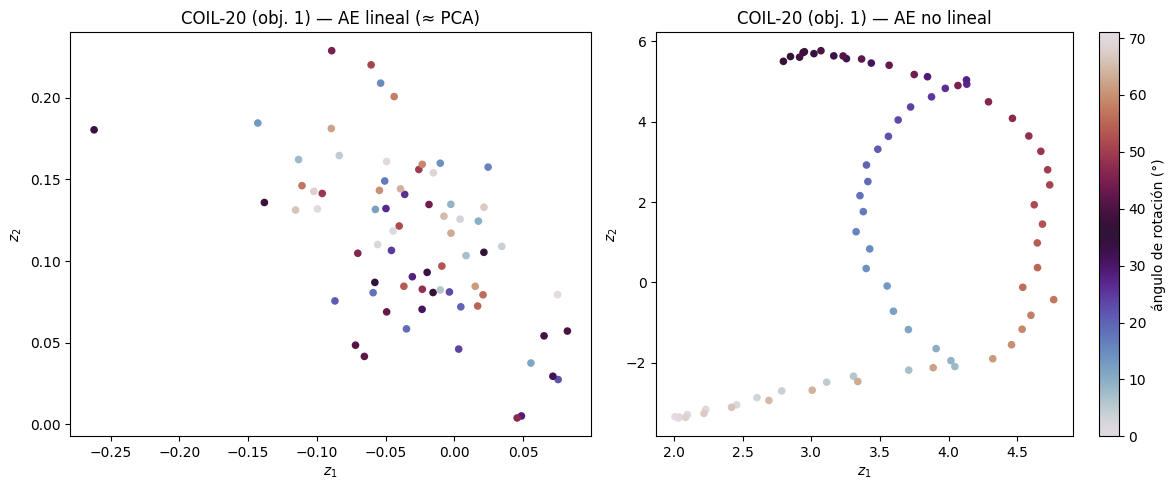

d=5: con dimensión de embebido >= 2, el lazo cerrado del giro puede representarse sin cortes -- de ahí la forma de anillo.


In [96]:
# COIL-20 (un objeto): espacio latente del AE lineal vs AE no lineal,
# coloreado por ángulo de rotación real -- si d>=2, debería verse como una
# circunferencia (o una elipse deformada) recorrida una vez por cada 360°.
if "coil20_object" in DATA:
    ds, meta, X = DATA["coil20_object"]
    d = get_latent_dim("coil20_object")
    z_ae = LATENT["coil20_object"]["linear_AE"]
    z_nl = LATENT["coil20_object"]["nonlinear_AE"]

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
    for ax, z, title in [(a1, z_ae, "AE lineal (≈ PCA)"), (a2, z_nl, "AE no lineal")]:
        if z.shape[1] >= 2:
            sc = ax.scatter(z[:, 0], z[:, 1], c=ds.labels, cmap="twilight", s=20)
            ax.set_ylabel("$z_2$")
        else:
            sc = ax.scatter(z[:, 0], np.zeros_like(z[:, 0]), c=ds.labels, cmap="twilight", s=20)
            ax.set_yticks([])
        ax.set_title(f"COIL-20 (obj. {COIL20_OBJECT_ID}) — {title}")
        ax.set_xlabel("$z_1$")
    fig.colorbar(sc, ax=a2, label="ángulo de rotación (°)")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "step11_coil20_object_latent.png"), dpi=150, bbox_inches="tight")
    plt.show()

    if d == 1:
        print(f"d={d}: el código latente es un único número real. Un giro completo "
              "(S^1) es topológicamente un lazo CERRADO; una recta real no puede "
              "representarlo sin un 'corte' (el ángulo justo antes y después de "
              "0°=360° queda en extremos opuestos del código, no contiguos). Por "
              "eso, aunque la dimensión intrínseca del giro es 1, verlo como una "
              "circunferencia en el plano requiere una dimensión de embebido >= 2 "
              "(exactamente lo que ocurre arriba si d resultó ser 2 o más).")
    else:
        print(f"d={d}: con dimensión de embebido >= 2, el lazo cerrado del giro "
              "puede representarse sin cortes -- de ahí la forma de anillo.")
else:
    print("Sin datos de COIL-20 cargados: se omite esta celda.")